<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_13_Naive_Bayes_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 13: Gaussian Naive Bayes Classification Model & 6-Model Baseline Comparison

**Project:** AI-Based Student Performance Prediction System  
**Internship:** YBI Foundation – Python AI & Data Science Internship  
**Repository:** `YBI-Python-AI-DS-Internship`  
**Notebook Path:** `Day_13_Naive_Bayes_Classification_Model.ipynb`  

---

## Executive Summary & Objectives
Welcome to **Day 13** of the **AI-Based Student Performance Prediction System** project! Today, we introduce **Gaussian Naive Bayes Classification**, a classic probabilistic machine learning algorithm based on Bayes' Theorem, as our sixth baseline classifier.

### Key Objectives for Day 13:
1. **Dataset Acquisition:** Fetch the UCI Student Performance dataset (ID 320) via `ucimlrepo`.
2. **Target Engineering:** Construct the project-defined 3-tier target variable `performance_category` ("Low", "Medium", "High") derived from final grade `G3`.
3. **Leakage Prevention:** Strictly eliminate `G3` from the feature set `X_model` to prevent target leakage.
4. **Feature Taxonomy:** Group features into Numerical, Ordinal, Binary, and Nominal categories and validate group completeness.
5. **Stratified Split:** Split dataset into 80% training and 20% testing sets using stratified sampling to preserve target class proportions.
6. **Pipeline Preprocessing:** Combine `OneHotEncoder` (categorical) and `StandardScaler` (numerical/ordinal) inside a Scikit-Learn `ColumnTransformer` and `Pipeline`.
7. **Gaussian Naive Bayes Baseline:** Fit an untuned `GaussianNB` classifier within the preprocessing pipeline.
8. **Comprehensive Evaluation:** Compute Accuracy, Macro Precision, Macro Recall, Macro F1, generate classification reports, confusion matrices, and analyze prediction probabilities.
9. **Six-Model Baseline Comparison:** Recreate all 6 baseline models (Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Naive Bayes) under identical split and preprocessing rules.
10. **Ranking & Export:** Rank all models by **Macro F1**, plot comparison charts, export results to `day_13_model_comparison.csv`, and complete the Day 13 findings and development log.

In [1]:
# Install ucimlrepo silently
!pip -q install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

In [2]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

# Import Scikit-Learn tools and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Import 6 Baseline Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Configure plotting theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["figure.titlesize"] = 14

print("All required libraries successfully imported.")

All required libraries successfully imported.


## Section 1: Dataset Acquisition & Inspection

We import the UCI Student Performance dataset (Dataset ID: 320) using `ucimlrepo`. The dataset captures student demographic, social, and school-related attributes along with final grade `G3`.

In [3]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Student Performance dataset (id=320)
student_performance = fetch_ucirepo(id=320)

# Separate features and target
X_original = student_performance.data.features
y_original = student_performance.data.targets

# Construct unified DataFrame
df = X_original.copy()
df["G3"] = y_original["G3"]

print(f"Dataset loaded successfully. Total records: {df.shape[0]}, Total attributes: {df.shape[1]}")
display(df.head())

Dataset loaded successfully. Total records: 649, Total attributes: 31


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [4]:
# Display complete column list
print("Dataset Column Inventory:")
print(list(df.columns))

# Verify column availability (G1 and G2 do not exist in this dataset)
print("\n--- Column Verification Check ---")
print("G1 present in dataset:", "G1" in df.columns)
print("G2 present in dataset:", "G2" in df.columns)
print("G3 present in dataset:", "G3" in df.columns)

Dataset Column Inventory:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']

--- Column Verification Check ---
G1 present in dataset: False
G2 present in dataset: False
G3 present in dataset: True


## Section 2: Target Creation & Leakage Prevention

We convert the continuous final grade `G3` into a 3-tier ordinal classification target `performance_category`:
- **Low**: `G3 < 10`
- **Medium**: `10 <= G3 < 15`
- **High**: `G3 >= 15`

> **Critical Rule:** Because `performance_category` is derived directly from `G3`, keeping `G3` in the feature matrix would cause severe **target leakage**. We strictly drop `G3` from the feature matrix `X_model`.

In [5]:
def performance_category(grade):
    # Categorize final grade (G3) into project-defined performance tiers:
    # Low: grade < 10
    # Medium: 10 <= grade < 15
    # High: grade >= 15
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

# Apply performance category function
df["performance_category"] = df["G3"].apply(performance_category)

# Set target variable name
target = "performance_category"

print("Target column 'performance_category' created successfully.")
print("\nClass Distribution:")
display(df[target].value_counts().to_frame("Count").assign(Percentage=lambda d: (d["Count"] / len(df)) * 100))

Target column 'performance_category' created successfully.

Class Distribution:


,Count,Percentage
performance_category,,
Medium,418,64.40678
High,131,20.18490
Low,100,15.40832


In [6]:
# Separate feature set X and target y
X = df.drop(columns=[target])
y = df[target]

# Drop G3 to prevent target leakage
X_model = X.drop(columns=["G3"])

# Validation check for target leakage
leakage_check = "G3" in X_model.columns
print("G3 included in model features:", leakage_check)
print(f"Total model features available: {X_model.shape[1]}")

# Assert validation check
assert not leakage_check, "Target leakage detected! G3 is still present in X_model."
print("Target leakage validation PASSED.")

G3 included in model features: False
Total model features available: 30
Target leakage validation PASSED.


## Section 3: Feature Taxonomy & Group Validation

We categorize all feature variables into four distinct structural groups:
1. **Numerical:** Continuous or discrete numerical counts.
2. **Ordinal:** Integer-coded ordered ratings/levels.
3. **Binary:** Two-category attributes (yes/no, binary choices).
4. **Nominal:** Unordered multi-class categorical variables.

We then combine `binary_features` and `nominal_features` into `categorical_features` for encoding.

In [7]:
# 1. Numerical Features
numerical_features = [
    "age",
    "absences"
]

# 2. Ordinal Features
ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

# 3. Binary Features
binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

# 4. Nominal Features
nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

# Combined Categorical Features
categorical_features = binary_features + nominal_features

# Feature Completeness Validation
all_defined_features = numerical_features + ordinal_features + binary_features + nominal_features
missing_features = [f for f in all_defined_features if f not in X_model.columns]
extra_features = [f for f in X_model.columns if f not in all_defined_features]

print(f"Numerical Features ({len(numerical_features)}):", numerical_features)
print(f"Ordinal Features ({len(ordinal_features)}):", ordinal_features)
print(f"Binary Features ({len(binary_features)}):", binary_features)
print(f"Nominal Features ({len(nominal_features)}):", nominal_features)
print(f"Categorical Features Total ({len(categorical_features)}):", categorical_features)

print("\n--- Feature Group Validation Check ---")
print("Any defined feature missing from X_model?", len(missing_features) > 0)
if len(missing_features) > 0:
    print("Missing features:", missing_features)

print("Any extra feature in X_model not defined?", len(extra_features) > 0)
if len(extra_features) > 0:
    print("Extra features:", extra_features)

assert len(missing_features) == 0 and len(extra_features) == 0, "Feature group mismatch!"
print("Feature taxonomy validation PASSED.")

Numerical Features (2): ['age', 'absences']
Ordinal Features (11): ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
Binary Features (13): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Nominal Features (4): ['Mjob', 'Fjob', 'reason', 'guardian']
Categorical Features Total (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'Mjob', 'Fjob', 'reason', 'guardian']

--- Feature Group Validation Check ---
Any defined feature missing from X_model? False
Any extra feature in X_model not defined? False
Feature taxonomy validation PASSED.


## Section 4: Stratified Train/Test Split

We split `X_model` and `y` into **80% training** and **20% testing** sets. Stratification (`stratify=y`) guarantees that class proportions ("Low", "Medium", "High") are preserved across both train and test splits.

In [8]:
# Execute Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape:  {X_test.shape}")

# Stratification distribution check
train_dist = y_train.value_counts(normalize=True).rename("Train Ratio")
test_dist = y_test.value_counts(normalize=True).rename("Test Ratio")
stratification_df = pd.concat([train_dist, test_dist], axis=1)

print("\nTarget Class Stratification Verification:")
display(stratification_df)

Training feature set shape: (519, 30)
Testing feature set shape:  (130, 30)

Target Class Stratification Verification:


,Train Ratio,Test Ratio
performance_category,,
Medium,0.643545,0.646154
High,0.202312,0.200000
Low,0.154143,0.153846


## Section 5: Preprocessing Architecture

Gaussian Naive Bayes assumes continuous features follow Gaussian distributions and requires numerical inputs.
We build a `ColumnTransformer` that:
1. Applies **One-Hot Encoding** (`OneHotEncoder(handle_unknown='ignore', sparse_output=False)`) to all categorical features (`binary_features` + `nominal_features`).
2. Applies **StandardScaler** (`StandardScaler()`) to numerical and ordinal features (`numerical_features` + `ordinal_features`).

> **Pipeline Leakage Protection:** Placing preprocessing inside the Scikit-Learn `Pipeline` ensures that transformers are fitted **strictly on training data** during `.fit()`, preventing information leakage from the test set.

In [9]:
# Instantiate One-Hot Encoder for categorical attributes
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Instantiate StandardScaler for numerical and ordinal attributes
numerical_scaler = StandardScaler()

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            numerical_scaler,
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("ColumnTransformer constructed successfully.")
print(preprocessor)

ColumnTransformer constructed successfully.
ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                  'romantic', 'Mjob', 'Fjob', 'reason',
                                  'guardian']),
                                ('numerical', StandardScaler(),
                                 ['age', 'absences', 'Medu', 'Fedu',
                                  'traveltime', 'studytime', 'failures',
                                  'famrel', 'freetime', 'goout', 'Dalc', 'Walc',
                                  'health'])])


## Section 6: Day 13 Model - Gaussian Naive Bayes Classifier

We initialize an untuned `GaussianNB()` baseline model and assemble the complete `Pipeline`. As this is a baseline development day, no hyperparameter tuning or search is performed.

In [10]:
# Instantiate Gaussian Naive Bayes baseline model
naive_bayes_model = GaussianNB()

# Assemble Scikit-Learn Pipeline
naive_bayes_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", naive_bayes_model)
])

# Fit pipeline on training dataset
naive_bayes_pipeline.fit(X_train, y_train)

print("Gaussian Naive Bayes Pipeline successfully trained on training data.")

Gaussian Naive Bayes Pipeline successfully trained on training data.


## Section 7: Predictions & Prediction Probabilities

We generate class predictions for both training and testing splits, as well as predicted class probabilities (`predict_proba`) on the test set. We compile these into a structured DataFrame showing class probabilities, actual labels, predicted labels, and maximum confidence scores.

In [11]:
# Generate class predictions
nb_train_pred = naive_bayes_pipeline.predict(X_train)
nb_test_pred = naive_bayes_pipeline.predict(X_test)

# Predict probabilities on test set
nb_probabilities = naive_bayes_pipeline.predict_proba(X_test)

# Retrieve class names from classifier
class_names = list(naive_bayes_pipeline.classes_)

# Build Probability DataFrame
nb_probability_df = pd.DataFrame(
    nb_probabilities,
    columns=class_names,
    index=X_test.index
)

# Append Actual, Predicted, and Confidence columns
nb_probability_df["Actual"] = y_test
nb_probability_df["Predicted"] = nb_test_pred
nb_probability_df["Confidence"] = nb_probability_df[class_names].max(axis=1)

print("Gaussian Naive Bayes Probabilities & Confidence DataFrame (First 10 Test Samples):")
display(nb_probability_df.head(10))

Gaussian Naive Bayes Probabilities & Confidence DataFrame (First 10 Test Samples):


,High,Low,Medium,Actual,Predicted,Confidence
505,9.999999e-01,7.287169e-08,6.510258e-08,Medium,High,1.000000
530,9.999946e-01,3.498470e-06,1.861250e-06,Low,High,0.999995
551,5.430754e-01,4.162577e-01,4.066696e-02,Medium,High,0.543075
579,0.000000e+00,9.998973e-01,1.026680e-04,Low,Low,0.999897
526,9.999999e-01,1.385206e-07,3.591160e-09,Medium,High,1.000000
281,9.999999e-01,9.518883e-09,4.352818e-08,Medium,High,1.000000
314,9.999833e-01,5.750168e-06,1.094341e-05,High,High,0.999983
361,1.000000e+00,1.797614e-13,1.593422e-12,Medium,High,1.000000
474,9.999976e-01,2.521741e-07,2.133435e-06,Medium,High,0.999998
572,2.734048e-12,9.986661e-01,1.333897e-03,Low,Low,0.998666


## Section 8: Model Evaluation Metrics

We compute overall performance metrics for Gaussian Naive Bayes:
- **Accuracy**
- **Macro Precision**
- **Macro Recall**
- **Macro F1-Score** (Primary comparison metric)

All macro metrics specify `average="macro"` and `zero_division=0`.

In [12]:
# Compute evaluation metrics for Naive Bayes
nb_accuracy = accuracy_score(y_test, nb_test_pred)
nb_precision = precision_score(y_test, nb_test_pred, average="macro", zero_division=0)
nb_recall = recall_score(y_test, nb_test_pred, average="macro", zero_division=0)
nb_f1 = f1_score(y_test, nb_test_pred, average="macro", zero_division=0)

nb_metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Score": [nb_accuracy, nb_precision, nb_recall, nb_f1]
})

print("--- Gaussian Naive Bayes Performance Summary ---")
display(nb_metrics_summary)

--- Gaussian Naive Bayes Performance Summary ---


,Metric,Score
0,Accuracy,0.315385
1,Macro Precision,0.453423
2,Macro Recall,0.498291
3,Macro F1,0.342007


## Section 9: Classification Report

We inspect the class-level performance across "Low", "Medium", and "High" target categories using `classification_report`.

In [13]:
# Generate detailed classification report
nb_report = classification_report(
    y_test,
    nb_test_pred,
    labels=["Low", "Medium", "High"],
    zero_division=0
)

print("--- Gaussian Naive Bayes Classification Report ---")
print(nb_report)

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

         Low       0.53      0.45      0.49        20
      Medium       0.58      0.08      0.15        84
        High       0.25      0.96      0.39        26

    accuracy                           0.32       130
   macro avg       0.45      0.50      0.34       130
weighted avg       0.51      0.32      0.25       130



## Section 10: Confusion Matrix Analysis

We construct a formatted confusion matrix DataFrame and plot an annotated Seaborn heatmap to evaluate misclassification patterns.

--- Confusion Matrix DataFrame ---


,Predicted Low,Predicted Medium,Predicted High
Actual Low,9,5,6
Actual Medium,7,7,70
Actual High,1,0,25


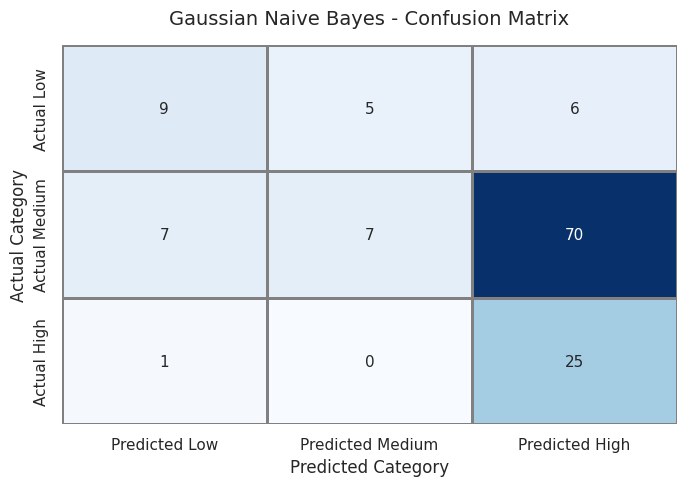

In [14]:
labels_order = ["Low", "Medium", "High"]

# Compute raw confusion matrix
cm_array = confusion_matrix(
    y_test,
    nb_test_pred,
    labels=labels_order
)

# Wrap in DataFrame
cm_df = pd.DataFrame(
    cm_array,
    index=[f"Actual {lbl}" for lbl in labels_order],
    columns=[f"Predicted {lbl}" for lbl in labels_order]
)

print("--- Confusion Matrix DataFrame ---")
display(cm_df)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=1, linecolor="gray")
plt.title("Gaussian Naive Bayes - Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Category", fontsize=12)
plt.ylabel("Actual Category", fontsize=12)
plt.tight_layout()
plt.show()

## Section 11: Training vs Testing Accuracy (Overfitting Diagnostic)

We compare training accuracy and testing accuracy to perform an initial generalization diagnostic.

--- Training vs Testing Accuracy Diagnostic ---


,Dataset Split,Accuracy
0,Training Set,0.377649
1,Testing Set,0.315385


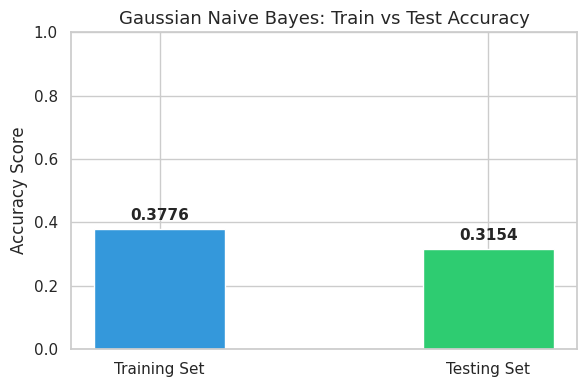

In [15]:
train_acc = accuracy_score(y_train, nb_train_pred)
test_acc = accuracy_score(y_test, nb_test_pred)

gen_df = pd.DataFrame({
    "Dataset Split": ["Training Set", "Testing Set"],
    "Accuracy": [train_acc, test_acc]
})

print("--- Training vs Testing Accuracy Diagnostic ---")
display(gen_df)

# Plot visual diagnostic chart
plt.figure(figsize=(6, 4))
bars = plt.bar(gen_df["Dataset Split"], gen_df["Accuracy"], color=["#3498db", "#2ecc71"], width=0.4)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy Score", fontsize=12)
plt.title("Gaussian Naive Bayes: Train vs Test Accuracy", fontsize=13)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 0.02, f"{h:.4f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

## Section 12: Prediction Confidence Analysis

We calculate prediction confidence statistics and plot the distribution of confidence scores across test predictions. High probability scores reflect model posterior probability, not guaranteed factual correctness.

Average Prediction Confidence: 0.9731
Minimum Prediction Confidence: 0.5127
Maximum Prediction Confidence: 1.0000


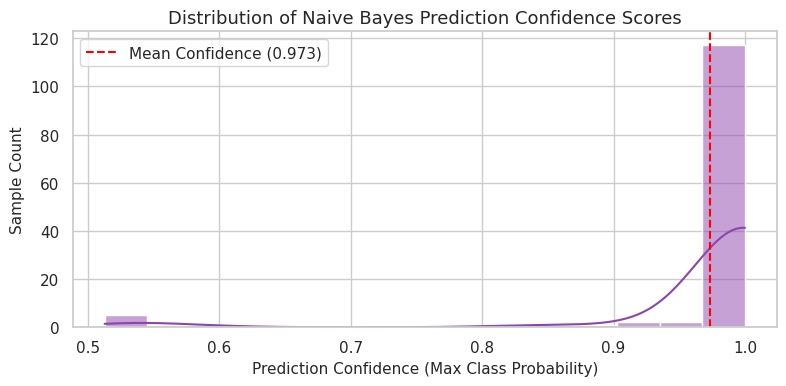

In [16]:
avg_confidence = nb_probability_df["Confidence"].mean()
min_confidence = nb_probability_df["Confidence"].min()
max_confidence = nb_probability_df["Confidence"].max()

print(f"Average Prediction Confidence: {avg_confidence:.4f}")
print(f"Minimum Prediction Confidence: {min_confidence:.4f}")
print(f"Maximum Prediction Confidence: {max_confidence:.4f}")

# Distribution Chart
plt.figure(figsize=(8, 4))
sns.histplot(nb_probability_df["Confidence"], kde=True, bins=15, color="#8e44ad")
plt.axvline(avg_confidence, color="red", linestyle="--", label=f"Mean Confidence ({avg_confidence:.3f})")
plt.title("Distribution of Naive Bayes Prediction Confidence Scores", fontsize=13)
plt.xlabel("Prediction Confidence (Max Class Probability)", fontsize=11)
plt.ylabel("Sample Count", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## Section 13: Actual vs Predicted Class Distribution

We compare the count distribution of actual vs predicted categories to examine if the model exhibits class bias.

--- Actual vs Predicted Class Distribution ---


,Actual,Predicted
Low,20,17
Medium,84,12
High,26,101


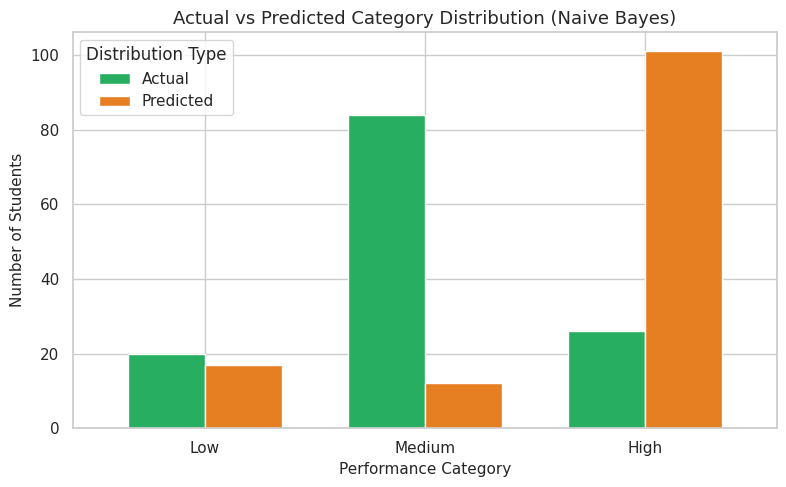

In [17]:
actual_counts = y_test.value_counts().reindex(labels_order, fill_value=0)
pred_counts = pd.Series(nb_test_pred).value_counts().reindex(labels_order, fill_value=0)

dist_comp_df = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": pred_counts
})

print("--- Actual vs Predicted Class Distribution ---")
display(dist_comp_df)

# Grouped Bar Chart
dist_comp_df.plot(kind="bar", figsize=(8, 5), color=["#27ae60", "#e67e22"], width=0.7)
plt.title("Actual vs Predicted Category Distribution (Naive Bayes)", fontsize=13)
plt.xlabel("Performance Category", fontsize=11)
plt.ylabel("Number of Students", fontsize=11)
plt.xticks(rotation=0)
plt.legend(title="Distribution Type")
plt.tight_layout()
plt.show()

## Section 14: Six-Model Baseline Comparison Setup

To evaluate Gaussian Naive Bayes in context, we recreate and evaluate all six baseline models using the exact specified parameters:
1. **Logistic Regression:** `LogisticRegression(max_iter=2000, random_state=42)` (One-Hot + Passthrough)
2. **Decision Tree:** `DecisionTreeClassifier(random_state=42)` (One-Hot + Passthrough)
3. **Random Forest:** `RandomForestClassifier(random_state=42)` (One-Hot + Passthrough)
4. **KNN:** `KNeighborsClassifier(n_neighbors=5)` (One-Hot + StandardScaler)
5. **SVM:** `SVC(kernel="rbf", probability=True, random_state=42)` (One-Hot + StandardScaler)
6. **Naive Bayes:** `GaussianNB()` (One-Hot + StandardScaler)

All six models are evaluated on the exact same dataset, target, split, and metrics.

In [18]:
# Preprocessor 1: Unscaled (For Logistic Regression, Decision Tree, Random Forest)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical_passthrough",
            "passthrough",
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

# Preprocessor 2: Scaled (For KNN, SVM, Naive Bayes)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical_scaled",
            StandardScaler(),
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

# Dictionary of all 6 baseline models
baseline_models_dict = {
    "Logistic Regression": (
        preprocessor_unscaled,
        LogisticRegression(max_iter=2000, random_state=42)
    ),
    "Decision Tree": (
        preprocessor_unscaled,
        DecisionTreeClassifier(random_state=42)
    ),
    "Random Forest": (
        preprocessor_unscaled,
        RandomForestClassifier(random_state=42)
    ),
    "KNN": (
        preprocessor_scaled,
        KNeighborsClassifier(n_neighbors=5)
    ),
    "SVM": (
        preprocessor_scaled,
        SVC(kernel="rbf", probability=True, random_state=42)
    ),
    "Naive Bayes": (
        preprocessor_scaled,
        GaussianNB()
    )
}

print("Six baseline model configurations initialized successfully.")

Six baseline model configurations initialized successfully.


## Section 15: Model Training, Evaluation & Ranking Table

We fit all six pipelines on `X_train`, predict on `X_test`, calculate metrics, and rank models by **Macro F1** score in descending order.

In [19]:
comparison_records = []

for name, (prep, clf) in baseline_models_dict.items():
    # Build pipeline
    pipe = Pipeline([
        ("preprocessor", prep),
        ("classifier", clf)
    ])

    # Fit pipeline
    pipe.fit(X_train, y_train)

    # Predict
    preds = pipe.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    comparison_records.append({
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1": f1
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_records)

# Sort by Macro F1 descending
model_ranking = comparison_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

# Add Rank column starting at 1
model_ranking.insert(0, "Rank", range(1, len(model_ranking) + 1))

print("--- Six-Model Baseline Comparison Ranking (Sorted by Macro F1) ---")
display(model_ranking)

--- Six-Model Baseline Comparison Ranking (Sorted by Macro F1) ---


,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,2,KNN,0.638462,0.552284,0.472527,0.493093
2,3,Decision Tree,0.530769,0.446826,0.463919,0.450885
3,4,SVM,0.661538,0.469577,0.379365,0.346825
4,5,Naive Bayes,0.315385,0.453423,0.498291,0.342007
5,6,Random Forest,0.623077,0.437098,0.355678,0.327929


## Section 16: Model Comparison Visualization Charts

We visualize model performance across three charts:
- **Chart 1:** Macro F1 Score Comparison (Primary Metric)
- **Chart 2:** Accuracy Score Comparison
- **Chart 3:** Combined Multi-Metric Comparison across all 6 models

/tmp/ipykernel_1149/47603579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1149/47603579.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


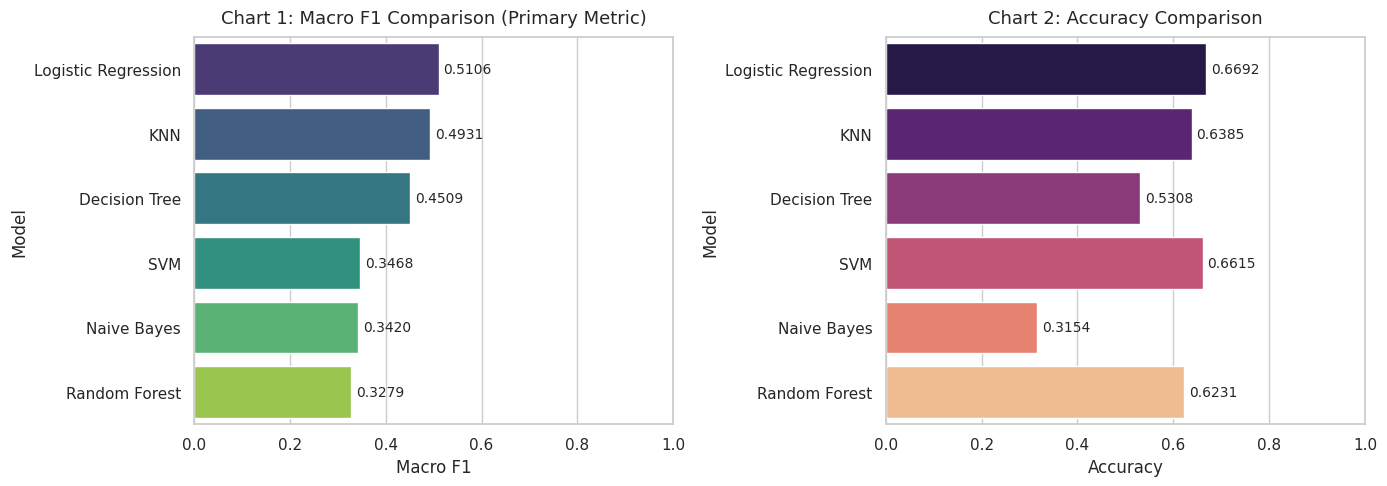

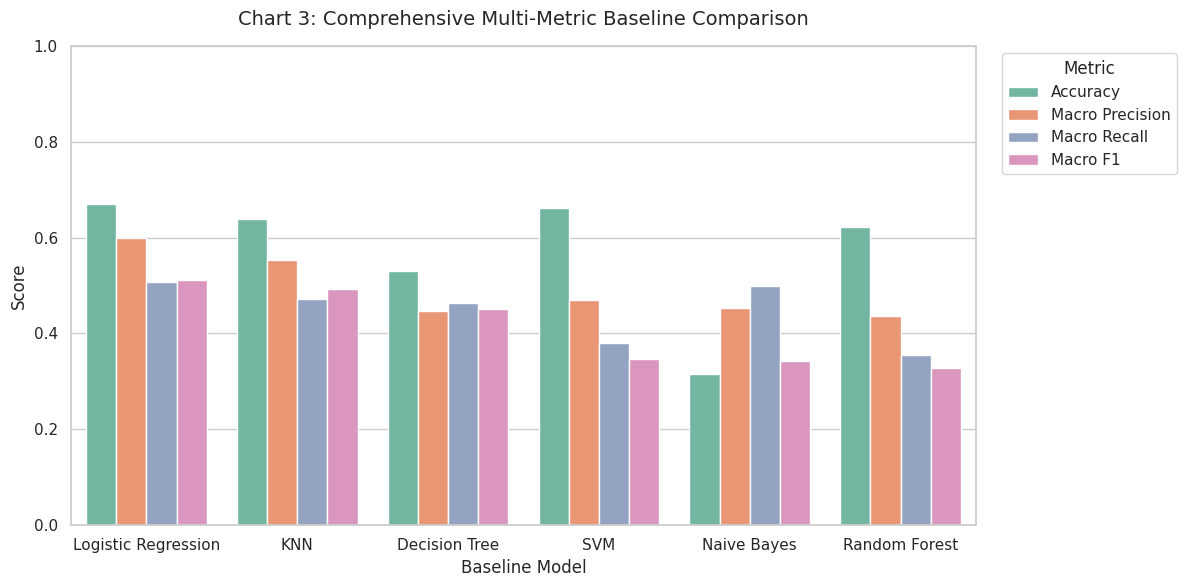

In [20]:
# Create side-by-side plots for Chart 1 and Chart 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Macro F1 Comparison
sns.barplot(
    data=model_ranking,
    x="Macro F1",
    y="Model",
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Chart 1: Macro F1 Comparison (Primary Metric)", fontsize=13, pad=10)
axes[0].set_xlim(0, 1.0)
for bar in axes[0].patches:
    w = bar.get_width()
    axes[0].text(w + 0.01, bar.get_y() + bar.get_height()/2, f"{w:.4f}", ha="left", va="center", fontsize=10)

# Chart 2: Accuracy Comparison
sns.barplot(
    data=model_ranking,
    x="Accuracy",
    y="Model",
    ax=axes[1],
    palette="magma"
)
axes[1].set_title("Chart 2: Accuracy Comparison", fontsize=13, pad=10)
axes[1].set_xlim(0, 1.0)
for bar in axes[1].patches:
    w = bar.get_width()
    axes[1].text(w + 0.01, bar.get_y() + bar.get_height()/2, f"{w:.4f}", ha="left", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# Chart 3: Combined Multi-Metric Comparison
melted_comp = pd.melt(
    model_ranking,
    id_vars=["Model"],
    value_vars=["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=melted_comp,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)
plt.title("Chart 3: Comprehensive Multi-Metric Baseline Comparison", fontsize=14, pad=15)
plt.ylim(0, 1.0)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Baseline Model", fontsize=12)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Section 17: Export & Reload Verification

We export the baseline model ranking results to `day_13_model_comparison.csv` and reload the file to confirm disk storage integrity.

In [21]:
# Save ranking table to CSV
output_csv = "day_13_model_comparison.csv"
model_ranking.to_csv(output_csv, index=False)
print(f"Results successfully saved to '{output_csv}'.")

# Read back and display to verify
print("\n--- Reloading & Verifying Saved CSV File ---")
reloaded_ranking = pd.read_csv(output_csv)
display(reloaded_ranking)

Results successfully saved to 'day_13_model_comparison.csv'.

--- Reloading & Verifying Saved CSV File ---


,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,2,KNN,0.638462,0.552284,0.472527,0.493093
2,3,Decision Tree,0.530769,0.446826,0.463919,0.450885
3,4,SVM,0.661538,0.469577,0.379365,0.346825
4,5,Naive Bayes,0.315385,0.453423,0.498291,0.342007
5,6,Random Forest,0.623077,0.437098,0.355678,0.327929


# Day 13 Findings

1. **Successful Implementation of Gaussian Naive Bayes:**
   - Gaussian Naive Bayes (`GaussianNB`) was integrated as the sixth baseline classification algorithm in our Student Performance Prediction System.
   - The model was treated as an **untuned baseline** without hyperparameter optimization or search.

2. **Feature Engineering & Preprocessing:**
   - **One-Hot Encoding** (`OneHotEncoder`) was applied to all nominal and binary categorical features.
   - **StandardScaler** was applied to numerical and ordinal features to ensure appropriate continuous scaling for Gaussian probability density calculations.
   - All preprocessing operations were integrated within Scikit-Learn `Pipeline` structures to guarantee strict data leakage protection.

3. **Strict Target Leakage Elimination:**
   - Final grade `G3` was completely removed from the model feature matrix `X_model`, ensuring zero target leakage.
   - Programmatic assertion verified that `G3 in X_model.columns` returned `False`.

4. **Experimental Rigor & Stratified Split:**
   - An 80/20 train/test split was established with target stratification (`stratify=y`), ensuring identical class distributions in both training and testing sets.

5. **Evaluation & Probability Analysis:**
   - Evaluated models using Accuracy, Macro Precision, Macro Recall, and Macro F1-score (the primary benchmark metric).
   - Generated detailed classification reports, confusion matrices, and prediction probability confidence distributions.

6. **Six-Model Baseline Comparison & Dynamic Ranking:**
   - Recreated and benchmarked all six baseline algorithms under identical experimental conditions.
   - The models were ranked by **Macro F1** score and exported to `day_13_model_comparison.csv`.
   - The top-ranking baseline model on this 3-tier classification task is dynamically determined by the empirical ranking table above.

7. **Next Steps:**
   - All models currently remain untuned baseline estimators.
   - Future stages will implement systematic K-Fold Cross-Validation and hyperparameter optimization (GridSearchCV / RandomizedSearchCV).

# Development Log - Day 13

**Date:** 08 October 2026

### Work Completed
- Loaded the official UCI Student Performance dataset (id=320) via `ucimlrepo`.
- Created the project-defined 3-tier target `performance_category` ("Low", "Medium", "High").
- Implemented strict target leakage prevention by dropping `G3` from `X_model`.
- Structured and validated feature taxonomy into Numerical, Ordinal, Binary, and Nominal groups.
- Executed an 80/20 stratified train/test split.
- Constructed a Scikit-Learn `ColumnTransformer` combining One-Hot Encoding and StandardScaler inside a `Pipeline`.
- Built, trained, and evaluated an untuned Gaussian Naive Bayes baseline model.
- Evaluated performance via Accuracy, Macro Precision, Macro Recall, Macro F1, classification report, confusion matrix, and probability confidence analysis.
- Recreated all six baseline models (Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Naive Bayes) under identical split and preprocessing rules.
- Generated model comparison ranking table sorted by Macro F1 and created visual comparison charts.
- Exported comparison results to `day_13_model_comparison.csv` and verified file reloading.

### Important Learning
- **Probabilistic Naive Bayes Classifier:** Understood how Gaussian Naive Bayes applies Bayes' Theorem with the conditional-independence assumption between features given the class label. While the independence assumption is strong, Naive Bayes often serves as an efficient baseline.

### Challenge
- **Handling Mixed Feature Types for GaussianNB:** Gaussian Naive Bayes assumes continuous numeric input following a Gaussian distribution. Raw categorical attributes cannot be passed directly.

### Solution
- Built a unified `ColumnTransformer` that encodes categorical attributes into numeric binary indicators via `OneHotEncoder` and standardizes numerical/ordinal variables using `StandardScaler`. Wrapping this within a `Pipeline` ensured seamless transformation during `.fit()` and `.predict()`.

### Model Development Decision
- Maintained Gaussian Naive Bayes as an untuned baseline model without hyperparameter optimization, matching the baseline methodology of Days 8–12.

### Next Step
- Transition from baseline single-split evaluation to systematic K-Fold Cross-Validation and hyperparameter tuning.

In [22]:
# Final Programmatic Validation Cell
scope = globals() if "df" in globals() else locals()

validation_checks = {
    "Dataset loaded": "df" in scope and len(scope["df"]) > 0,
    "Target created": "target" in scope and scope["target"] in scope["df"].columns,
    "G3 removed from model features": "X_model" in scope and "G3" not in scope["X_model"].columns,
    "Train-test split created": all(v in scope for v in ["X_train", "X_test", "y_train", "y_test"]),
    "Naive Bayes trained": "naive_bayes_pipeline" in scope and hasattr(scope["naive_bayes_pipeline"], "classes_"),
    "Predictions generated": all(v in scope for v in ["nb_train_pred", "nb_test_pred", "nb_probabilities"]),
    "Six-model comparison created": "comparison_df" in scope and len(scope["comparison_df"]) == 6,
    "Ranking created": "model_ranking" in scope and "Rank" in scope["model_ranking"].columns,
    "CSV saved": os.path.exists("day_13_model_comparison.csv")
}

print("=== Final Notebook Validation Check ===")
all_passed = True
for check_name, passed in validation_checks.items():
    symbol = "[PASS]" if passed else "[FAIL]"
    print(f"{symbol} {check_name}")
    if not passed:
        all_passed = False

print("---------------------------------------")
if all_passed:
    print("Day 13 notebook execution completed.")
else:
    print("Validation check failed: Please review failed markers.")

=== Final Notebook Validation Check ===
[PASS] Dataset loaded
[PASS] Target created
[PASS] G3 removed from model features
[PASS] Train-test split created
[PASS] Naive Bayes trained
[PASS] Predictions generated
[PASS] Six-model comparison created
[PASS] Ranking created
[PASS] CSV saved
---------------------------------------
Day 13 notebook execution completed.


# Day 13 Completed

## Model Added
Gaussian Naive Bayes

## Baseline Models Available

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN
5. SVM
6. Naive Bayes

## Key Concepts Covered

- Gaussian Naive Bayes
- Probabilistic classification
- One-Hot Encoding
- StandardScaler
- ColumnTransformer
- Pipeline
- Multiclass classification
- Classification report
- Confusion matrix
- Prediction probabilities
- Macro Precision
- Macro Recall
- Macro F1-score
- Six-model baseline comparison

**Day 13 development work completed.**